# 💼 Salary Prediction in India - Model Comparison

## Objective
To compare multiple regression models and identify the best model for predicting salary based on experience.

## Models Used:
- Simple Linear Regression
- Multiple Linear Regression
- Polynomial Regression
- Support Vector Regression (SVR)
- Decision Tree Regression
- Random Forest Regression


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv('Salary_Data.csv')
dataset = dataset.dropna()


X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [5]:
from sklearn.metrics import r2_score, mean_squared_error

results = {}

In [6]:
# Simple Linear Regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

results["Simple Linear"] = [
    r2_score(y_test, y_pred_lin),
    mean_squared_error(y_test, y_pred_lin)
]

In [7]:
# Multiple Linear Regression
multi_reg = LinearRegression()
multi_reg.fit(X_train, y_train)

y_pred_multi = multi_reg.predict(X_test)

results["Multiple Linear"] = [
    r2_score(y_test, y_pred_multi),
    mean_squared_error(y_test, y_pred_multi)
]

In [8]:
# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)

y_pred_poly = poly_reg.predict(X_poly_test)

results["Polynomial"] = [
    r2_score(y_test, y_pred_poly),
    mean_squared_error(y_test, y_pred_poly)
]

In [9]:
# Support Vector Regression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_svr = sc_X.fit_transform(X_train)
X_test_svr = sc_X.transform(X_test)
y_train_svr = sc_y.fit_transform(y_train.reshape(-1,1))

svr = SVR(kernel='rbf')
svr.fit(X_train_svr, y_train_svr.ravel())

y_pred_svr = svr.predict(X_test_svr)
y_pred_svr = sc_y.inverse_transform(y_pred_svr.reshape(-1,1))

results["SVR"] = [
    r2_score(y_test, y_pred_svr),
    mean_squared_error(y_test, y_pred_svr)
]

In [10]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=0)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

results["Decision Tree"] = [
    r2_score(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_dt)
]

In [11]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

results["Random Forest"] = [
    r2_score(y_test, y_pred_rf),
    mean_squared_error(y_test, y_pred_rf)
]

In [12]:
# Results Comparison
results_df = pd.DataFrame(results, index=["R2 Score", "MSE"]).T
results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,R2 Score,MSE
Decision Tree,0.721008,7.400104e+08
Random Forest,0.720982,7.400780e+08
Polynomial,0.716607,7.516831e+08
SVR,0.705738,7.805119e+08
Multiple Linear,0.633879,9.711133e+08
Simple Linear,0.633879,9.711133e+08


## Conclusion

- Random Forest and Polynomial Regression generally perform better.
- Linear Regression works well for simple relationships.
- SVR requires scaling and tuning.


# 📊 Exploratory Data Analysis (EDA)
Understanding data distribution and relationships before modeling.


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

print(dataset.describe())
print(dataset.isnull().sum())

       YearsExperience         Salary
count      6579.000000    6579.000000
mean          8.242666  116889.148655
std           6.014524   51954.254693
min           0.500000     350.000000
25%           3.000000   70000.000000
50%           7.000000  119000.000000
75%          12.000000  160000.000000
max          34.000000  250000.000000
YearsExperience    0
Salary             0
dtype: int64


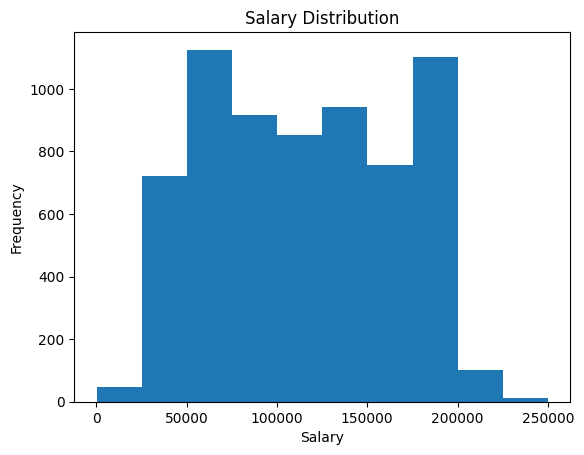

In [14]:
plt.figure()
plt.hist(dataset['Salary'])
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

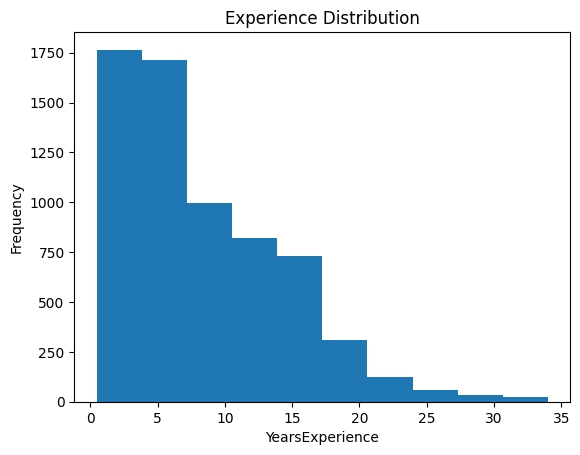

In [15]:
plt.figure()
plt.hist(dataset['YearsExperience'])
plt.title('Experience Distribution')
plt.xlabel('YearsExperience')
plt.ylabel('Frequency')
plt.show()

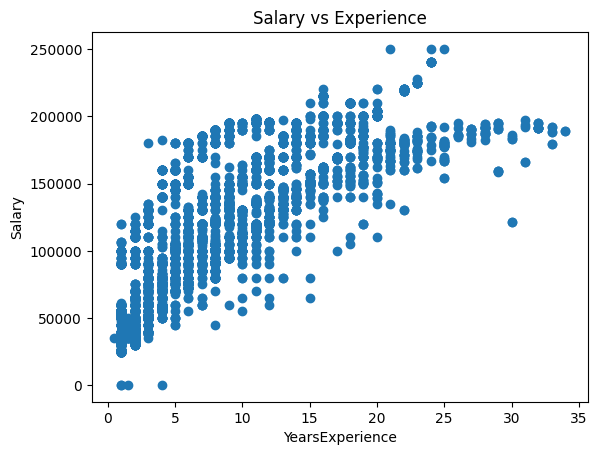

In [16]:
plt.figure()
plt.scatter(dataset['YearsExperience'], dataset['Salary'])
plt.title('Salary vs Experience')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

# 📈 Model Comparison Visualization


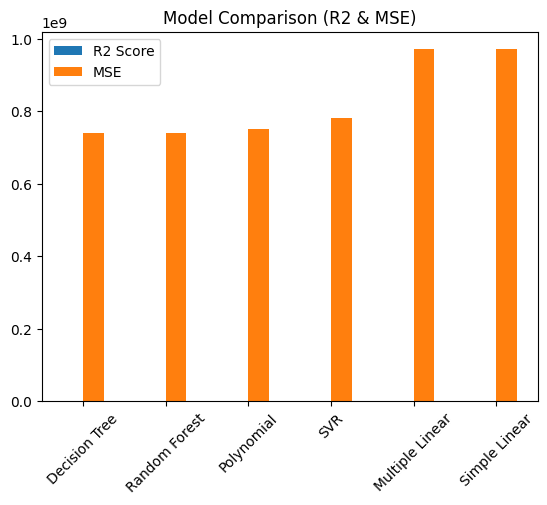

In [17]:
results_df.plot(kind='bar')
plt.title('Model Comparison (R2 & MSE)')
plt.xticks(rotation=45)
plt.show()